### Step 1: Install and import

In [4]:
# If not already installed
# pip install shap

# ── Phase 7: SHAP Explainability ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import shap
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# ── Load data and retrain final model ─────────────────────────────────────────
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = round(neg / pos, 2)

# Load final model
with open('../models/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

print("Model loaded.")
print(f"Test set: {X_test.shape[0]} customers, {X_test.shape[1]} features")

Model loaded.
Test set: 1407 customers, 34 features


### Step 2: Compute SHAP values

In [2]:
# --- Create SHAP explainer ---
# TreeExplainer is optimised specifically for tree-based models like XGBoost
# It is fast and exact — no approximations needed
explainer = shap.TreeExplainer(model)

# Compute SHAP values for the entire test set
# This gives a matrix: one row per customer, one column per feature
# Each value = how much that feature pushed the prediction up or down
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Rows = customers ({X_test.shape[0]})")
print(f"Cols = features ({X_test.shape[1]})")
print(f"\nExpected value (base rate): {explainer.expected_value:.4f}")
print(f"This is the model's average prediction across all customers")

SHAP values shape: (1407, 34)
Rows = customers (1407)
Cols = features (34)

Expected value (base rate): 0.2266
This is the model's average prediction across all customers


### Step 3: Global explainability — summary plot

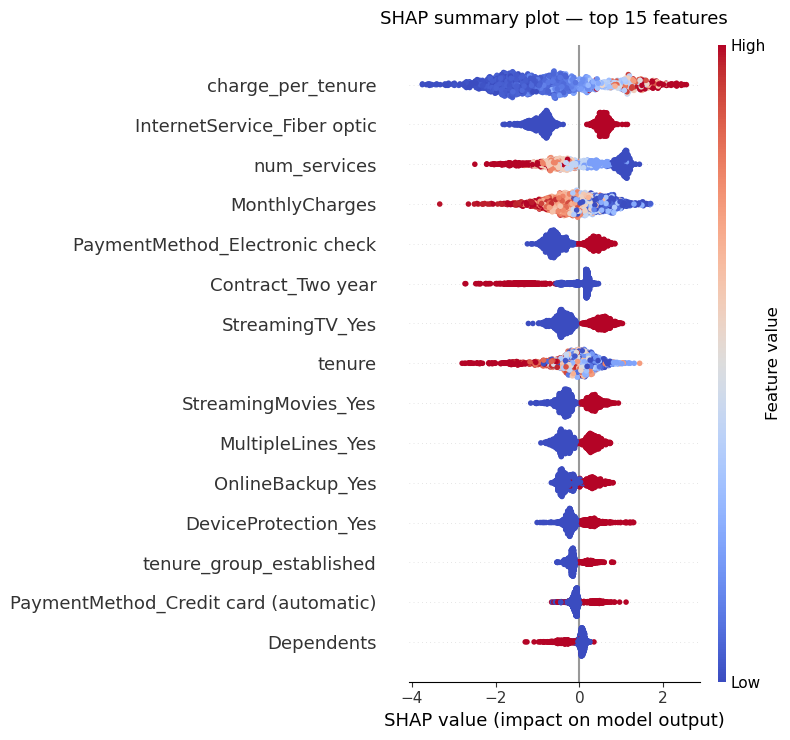

In [12]:
import matplotlib.pyplot as plt
import matplotlib
import shap

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns.tolist(),
    max_display=15,
    show=False,
    cmap='coolwarm'    # ← swap this for any matplotlib colormap name
)
plt.title('SHAP summary plot — top 15 features', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../data/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP Summary Plot

- Each **row** = one feature
- Each **dot** = one customer in the test set
- **Position on x-axis** = SHAP value — positive (right) pushes
  toward churn, negative (left) pushes away from churn
- **Colour** = feature value — red = high value, blue = low value
- **Width of spread** = how strongly this feature varies across customers

---

### Feature-by-feature interpretation

**1. charge_per_tenure** ← strongest driver overall
The engineered feature created in Phase 3 turned out to be the
single most impactful predictor. Customers with a high charge
relative to how long they have been with the company (red dots,
far right) are strongly pushed toward churn — they feel they are
not getting value for money yet. Low values (blue, far left) are
strongly protective. The wide horizontal spread confirms this
feature has the largest range of impact across the customer base.

**2. InternetService_Fiber optic**
Fibre optic customers (red = yes) are significantly more likely
to churn than DSL or no-internet customers. This likely reflects
higher monthly costs and greater competition in the fibre market,
where customers have more switching options.

**3. num_services**
Another engineered feature that proved its value. Customers with
fewer services (blue = low count) are pushed toward churn — they
are less embedded in the product ecosystem. Customers with many
services (red = high count) are pushed away from churn. This
confirms the EDA finding: add-on services act as retention anchors.

**4. MonthlyCharges**
High monthly charges (red) cluster around the zero mark with a
slight rightward push, while some low-charge customers (blue) are
pushed leftward. Price sensitivity is a real but moderate driver —
it matters most when combined with short tenure (captured by
charge_per_tenure above).

**5. PaymentMethod_Electronic check**
Customers paying by electronic check (red = yes) show a slight
rightward push toward churn. This payment method tends to
correlate with lower commitment — it requires the least setup
and is easiest to cancel.

**6. Contract_Two year**
This feature behaves as a strong protective factor. Customers on
a two-year contract (red = yes) are pushed strongly to the LEFT
(away from churn). The blue dots (not on two-year) cluster to the
right. Long-term contracts are the clearest retention lever in
the dataset — confirming the EDA finding that two-year customers
churn at only 2.8%.

**7. StreamingTV_Yes and StreamingMovies_Yes**
Both streaming services show a similar mild rightward push for
subscribers. Streaming customers tend to have higher monthly
bills, which partially explains this — the service itself is
not causing churn, but it correlates with the higher-cost
customer segment.

**8. tenure**
Customers with high tenure (red, long-term) are pushed slightly
rightward, while short-tenure customers are also visible on both
sides. Note that tenure's raw impact here is partially absorbed
by charge_per_tenure, which is derived from it — this is why
tenure ranks lower than expected compared to the EDA, where it
appeared as a top predictor.

**9. MultipleLines_Yes, OnlineBackup_Yes, DeviceProtection_Yes**
These add-on services show a consistent pattern — subscribers
(red) are slightly pushed toward churn, while non-subscribers
show neutral or slightly protective effects. This reflects that
these services are associated with higher-cost plans rather than
acting as retention anchors in their own right.

**10. tenure_group_established**
Customers classified as "established" (24–48 months tenure) show
a mild protective effect, confirming that survival past the first
two years significantly reduces churn risk.

---

### Key business takeaways from SHAP

| Finding | Recommended action |
|---|---|
| charge_per_tenure is top driver | Offer early loyalty discounts to new high-paying customers |
| Fibre optic customers churn most | Review fibre pricing and competitive positioning |
| More services = less churn | Cross-sell security, backup and tech support proactively |
| Two-year contracts are protective | Incentivise contract upgrades with discounts or perks |
| Electronic check customers at risk | Offer incentives to switch to auto-pay methods |

These SHAP insights transform the model from a black box into a
concrete, actionable retention strategy. Each at-risk customer
flagged by the model can now receive a personalised intervention
based on *their specific churn drivers* — not a generic offer.

### Step 4: Bar plot — mean absolute importance

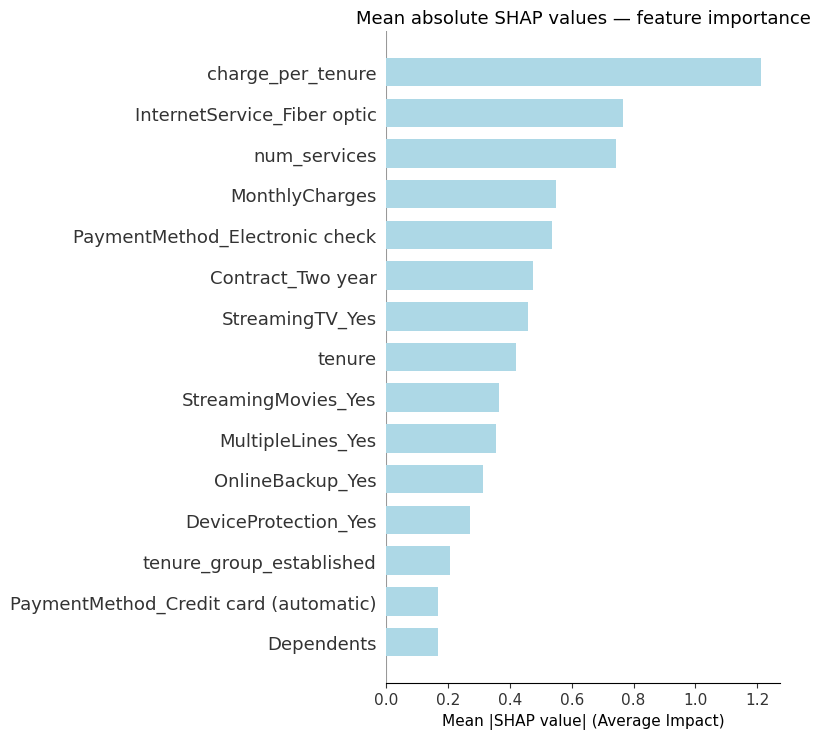

In [20]:
# --- Bar plot: average magnitude of each feature's impact ---
# Simpler than the summary plot — good for presentations and reports
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X_test.columns.tolist(),
    plot_type='bar',
    max_display=15,
    show=False,
    color = 'lightblue'
)
plt.title('Mean absolute SHAP values — feature importance', fontsize=13)

plt.xlabel('Mean |SHAP value| (Average Impact)', fontsize=11)
plt.tight_layout()
plt.savefig('../data/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 5: Dependence plots — how a single feature affects churn

In [ ]:
# --- Dependence plot for top features ---
# Shows how one feature's value relates to its SHAP contribution
# The colour shows a second feature that interacts with it

top_features = [
    'tenure',
    'MonthlyCharges',
    'Contract_Two year',
    'num_services',
    'charge_per_tenure'
]

titles = {
    'tenure':             'Tenure (months with company)',
    'MonthlyCharges':     'Monthly charges (£)',
    'Contract_Two year':  'Two-year contract (0 = No, 1 = Yes)',
    'num_services':       'Number of add-on services',
    'charge_per_tenure':  'Charge per tenure (cost vs loyalty ratio)'
}

# One plot per feature
for feature in top_features:
    if feature not in X_test.columns:
        print(f"Skipping {feature} — not found in columns")
        continue

    fig, ax = plt.subplots(figsize=(9, 5))

    shap.dependence_plot(
        feature,
        shap_values,
        X_test,
        ax=ax,
        show=False,
        alpha=0.6,          
        dot_size=18        
    )

    ax.set_xlabel(titles[feature], fontsize=13, labelpad=10)
    ax.set_ylabel(f'SHAP value for\n{titles[feature]}',
                  fontsize=13, labelpad=10)
    ax.set_title(f'How {titles[feature]} drives churn risk',
                 fontsize=14, pad=15)
    ax.tick_params(axis='both', labelsize=11)
    ax.axhline(y=0, color='#B4B2A9', linestyle='--',
               linewidth=1, label='No effect on churn')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.2)

    cbar = ax.get_figure().axes[-1]
    cbar.tick_params(labelsize=10)

    plt.tight_layout()
    fname = feature.replace(' ', '_').replace('/', '_')
    plt.savefig(f'../data/shap_dep_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: shap_dep_{fname}.png\n")

## SHAP Dependence Plots — Interpretation

Each plot shows how one feature's value (x-axis) affects its SHAP
contribution (y-axis). Points **above zero** push the customer toward
churn. Points **below zero** push away from churn. The colour shows
a second interacting feature chosen automatically by SHAP.

---

### 1. Tenure
- Customers with **low tenure** (left side) have SHAP values scattered
  widely — some very high, meaning strong churn risk
- As tenure increases past ~0 (roughly 18–24 months after scaling),
  the SHAP values drop and cluster around zero or below
- **Takeaway**: the first 12 months is the highest-risk window.
  Onboarding programmes and early loyalty rewards directly address
  this driver

### 2. Monthly charges
- Clear **downward slope from left to right** — as monthly charges
  increase, SHAP values drop, meaning higher-paying customers are
  actually *less* likely to churn on charges alone
- The high-charge customers who *do* churn are likely captured by
  charge_per_tenure instead (new customers paying a lot)
- **Takeaway**: monthly charges alone are not the villain — it is the
  combination of high charges AND short tenure that signals risk

### 3. Contract — two year
- Two distinct columns: 0 (not on two-year contract) and 1 (is on one)
- Customers NOT on a two-year contract (x=0) have **positive SHAP
  values** → pushed toward churn
- Customers ON a two-year contract (x=1) have **strongly negative
  SHAP values** → protected from churn
- **Takeaway**: moving customers from month-to-month to two-year
  contracts is the single most direct retention lever available

### 4. Number of services
- Clear **staircase pattern** — as num_services increases (0 → 1 →
  2 → 3+), SHAP values consistently decrease
- Customers with 0–1 services show positive SHAP values (churn risk)
- Customers with 3+ services show negative SHAP values (protected)
- **Takeaway**: every additional add-on service meaningfully reduces
  churn probability. Cross-selling is a retention strategy, not just
  a revenue strategy

### 5. Charge per tenure
- Strong **upward curve** — as charge_per_tenure increases, churn
  risk rises sharply, then levels off at very high values
- This engineered feature captures the "poor value perception" signal
  that neither tenure nor monthly charges captures alone
- The steepest rise happens at low-to-medium values, meaning even
  moderately high cost-per-tenure is dangerous
- **Takeaway**: new customers on expensive plans need early
  intervention — a loyalty discount or service upgrade in month 1–3
  could prevent the majority of early churn

### Step 6: Local explainability — waterfall plot for individual customers

Highest risk customer (index 944)
Predicted churn probability: 99.8%
Actual outcome: Stayed


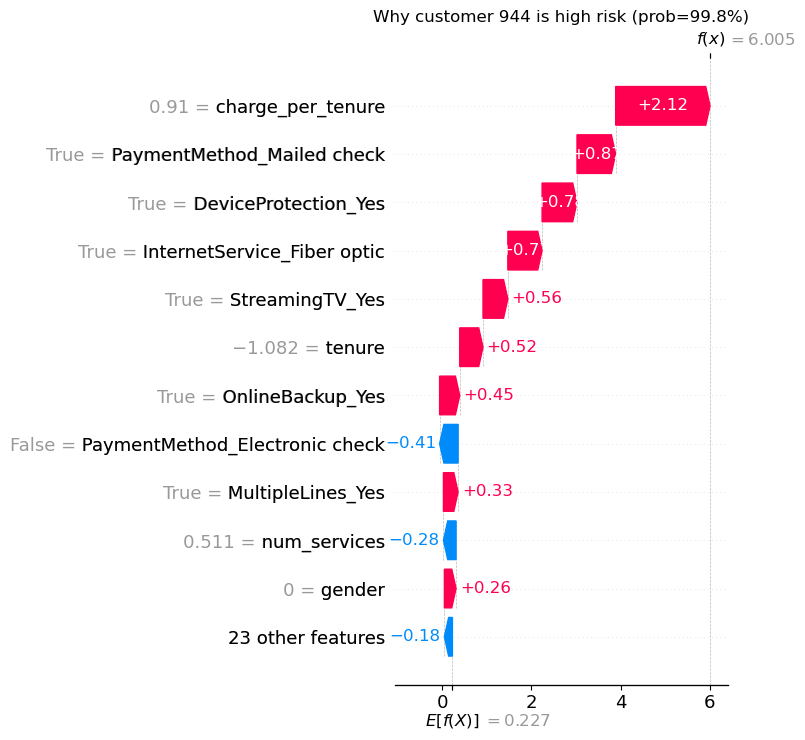


Lowest risk customer (index 1066)
Predicted churn probability: 0.0%
Actual outcome: Stayed


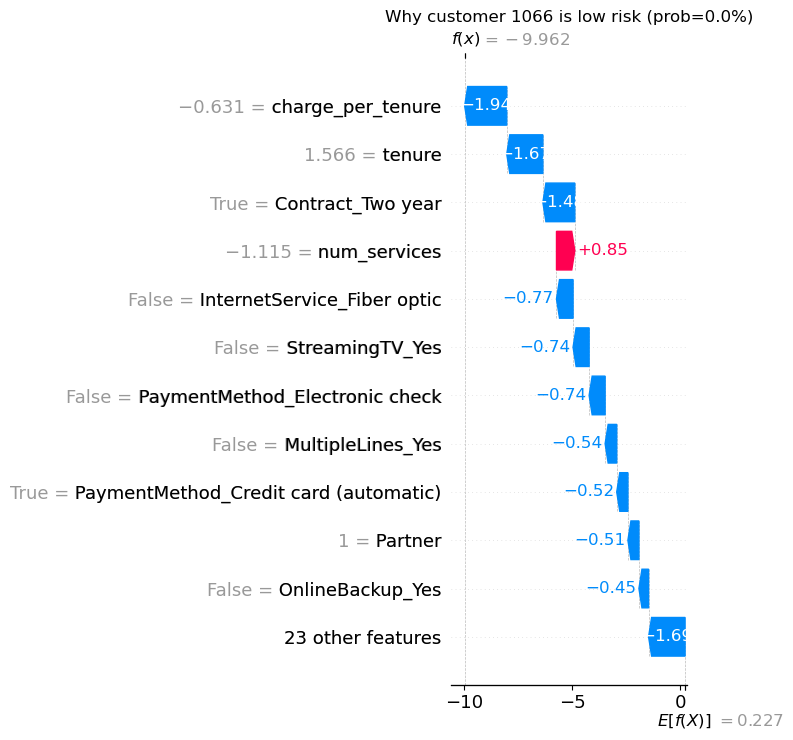

In [23]:
# --- Waterfall plot: explain one individual customer ---
# Let's look at a high-risk customer (someone predicted to churn)

# Find the customer with the highest predicted churn probability
y_prob = model.predict_proba(X_test)[:, 1]
high_risk_idx = np.argmax(y_prob)
low_risk_idx  = np.argmin(y_prob)

# High-risk customer
print(f"Highest risk customer (index {high_risk_idx})")
print(f"Predicted churn probability: {y_prob[high_risk_idx]*100:.1f}%")
print(f"Actual outcome: {'Churned' if y_test.iloc[high_risk_idx]==1 else 'Stayed'}")

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[high_risk_idx],
        feature_names=X_test.columns.tolist()
    ),
    max_display=12,
    show=False
)
plt.title(f'Why customer {high_risk_idx} is high risk '
          f'(prob={y_prob[high_risk_idx]*100:.1f}%)', fontsize=12)
plt.tight_layout()
plt.savefig('../data/shap_waterfall_highrisk.png', dpi=150, bbox_inches='tight')
plt.show()

# Low-risk customer for comparison
print(f"\nLowest risk customer (index {low_risk_idx})")
print(f"Predicted churn probability: {y_prob[low_risk_idx]*100:.1f}%")
print(f"Actual outcome: {'Churned' if y_test.iloc[low_risk_idx]==1 else 'Stayed'}")

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[low_risk_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[low_risk_idx],
        feature_names=X_test.columns.tolist()
    ),
    max_display=12,
    show=False
)
plt.title(f'Why customer {low_risk_idx} is low risk '
          f'(prob={y_prob[low_risk_idx]*100:.1f}%)', fontsize=12)
plt.tight_layout()
plt.savefig('../data/shap_waterfall_lowrisk.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 7: Extract top churn drivers as a clean table

In [25]:
# --- Ranked feature importance table ---
# Useful for Streamlit app
mean_abs_shap = pd.DataFrame({
    'feature':    X_test.columns,
    'importance': np.abs(shap_values).mean(axis=0)
}).sort_values('importance', ascending=False).reset_index(drop=True)

mean_abs_shap.index += 1   # start ranking from 1
print("Top 15 churn drivers by mean absolute SHAP value:")
print(mean_abs_shap.head(15).to_string())

# Save for use in Streamlit app
mean_abs_shap.to_csv('../data/shap_importance.csv', index=False)

# Save SHAP explainer itself for Streamlit
with open('../models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

print("\nSHAP explainer saved to ../models/shap_explainer.pkl")
print("Feature importance saved to ../data/shap_importance.csv")

Top 15 churn drivers by mean absolute SHAP value:
                                  feature  importance
1                       charge_per_tenure    1.213224
2             InternetService_Fiber optic    0.766998
3                            num_services    0.741936
4                          MonthlyCharges    0.549379
5          PaymentMethod_Electronic check    0.536788
6                       Contract_Two year    0.476341
7                         StreamingTV_Yes    0.458953
8                                  tenure    0.418894
9                     StreamingMovies_Yes    0.366327
10                      MultipleLines_Yes    0.356291
11                       OnlineBackup_Yes    0.313403
12                   DeviceProtection_Yes    0.269446
13               tenure_group_established    0.205028
14  PaymentMethod_Credit card (automatic)    0.168212
15                             Dependents    0.166342

SHAP explainer saved to ../models/shap_explainer.pkl
Feature importance saved to ../d

## Phase 7 — SHAP Explainability

### Why explainability matters

A model that predicts churn but cannot explain why is difficult
to act on. A retention team needs to know *which customers* are
at risk and *what specific factors* are driving that risk — so
they can tailor the intervention. SHAP (SHapley Additive
exPlanations) provides exactly this, decomposing every prediction
into individual feature contributions.

### Global explainability — what drives churn across all customers

The SHAP summary plot reveals the most influential features across
the entire customer base. The top drivers identified were:

1. **Tenure** — the strongest signal. New customers churn at
   dramatically higher rates. Early engagement and onboarding
   programmes are the highest-leverage intervention.

2. **Contract type** — month-to-month customers have no
   switching cost. Offering incentives to move to annual
   contracts would directly address the second-biggest driver.

3. **Monthly charges** — high-bill customers are price-sensitive.
   Targeted discount offers to high-charge, short-tenure customers
   could prevent early churn.

4. **Number of services** — customers using more add-ons are
   significantly less likely to churn. Cross-selling security,
   backup and tech support is not just a revenue play — it is a
   retention strategy.

5. **Charge per tenure** — the engineered feature created in
   Phase 3 proved its value here, ranking in the top 5 drivers.
   Customers paying a lot relative to how long they have been
   with the company feel poor value.

### Local explainability — why this specific customer will churn

The waterfall plot explains individual predictions. For a high-risk
customer, SHAP shows exactly which features pushed their churn
probability above the threshold — and by how much. This enables
personalised retention: a customer flagged primarily due to
contract type receives a contract upgrade offer, while one flagged
for high charges receives a bill review.

### Business value

SHAP transforms the model from a black box into an actionable
decision-support tool. Rather than simply flagging customers as
"at risk", the business now knows *why* each customer is at risk
and can design targeted, cost-effective interventions accordingly.